In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

import joblib

In [2]:
# Load the feature-engineered dataset
df = pd.read_csv(
    "../data/processed/lending_club_clean.csv",
    parse_dates=["issue_d", "earliest_cr_line"]
)

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

df.head()

DATASET INFORMATION
Rows    : 2,260,638
Columns : 36


,loan_amnt,term,int_rate,installment,grade,sub_grade,loan_status,purpose,issue_d,annual_inc,...,total_bc_limit,tot_hi_cred_lim,addr_state,application_type,default_flag,credit_score,income_group,loan_amount_group,interest_rate_group,issue_year
0,3600.0,36.0,13.99,123.03,C,C4,Fully Paid,debt_consolidation,2015-12-01,55000.0,...,2400.0,178050.0,PA,Individual,0,677.0,Middle,Small,High,2015
1,24700.0,36.0,11.99,820.28,C,C1,Fully Paid,small_business,2015-12-01,65000.0,...,79300.0,314017.0,SD,Individual,0,717.0,Middle,Large,Moderate,2015
2,20000.0,60.0,10.78,432.66,B,B4,Fully Paid,home_improvement,2015-12-01,63000.0,...,6200.0,218418.0,IL,Joint App,0,697.0,Middle,Large,Moderate,2015
3,35000.0,60.0,14.85,829.90,C,C5,Current,debt_consolidation,2015-12-01,110000.0,...,62500.0,381215.0,NJ,Individual,0,787.0,High,Very Large,High,2015
4,10400.0,60.0,22.45,289.91,F,F1,Fully Paid,major_purchase,2015-12-01,104433.0,...,20300.0,439570.0,PA,Individual,0,697.0,High,Medium,Very High,2015


In [3]:
print("\nMissing Values")
display(df.isnull().sum())

print("\nTarget Distribution")
display(df["default_flag"].value_counts())

print("\nTarget Percentage")
display(
    round(
        df["default_flag"].value_counts(normalize=True) * 100,
        2
    )
)


Missing Values


loan_amnt                 0
term                      0
int_rate                  0
installment               0
grade                     0
sub_grade                 0
loan_status               0
purpose                   0
issue_d                   0
annual_inc                0
emp_length                0
home_ownership            0
verification_status       0
fico_range_low            0
fico_range_high           0
dti                       0
open_acc                  0
pub_rec                   0
revol_bal                 0
revol_util                0
total_acc                 0
delinq_2yrs               0
inq_last_6mths            0
earliest_cr_line          0
mort_acc                  0
tot_cur_bal               0
total_bc_limit            0
tot_hi_cred_lim           0
addr_state                0
application_type          0
default_flag              0
credit_score              0
income_group           1667
loan_amount_group         0
interest_rate_group       0
issue_year          


Target Distribution


default_flag
0    1966223
1     294415
Name: count, dtype: int64


Target Percentage


default_flag
0    86.98
1    13.02
Name: proportion, dtype: float64

In [4]:
features = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "purpose",
    "annual_inc",
    "emp_length",
    "home_ownership",
    "verification_status",
    "credit_score",
    "dti",
    "open_acc",
    "revol_util",
    "total_acc",
    "mort_acc",
    "income_group",
    "interest_rate_group",
    "application_type",
]

X = df[features].copy()
y = df["default_flag"]

print("Feature Matrix :", X.shape)
print("Target Shape   :", y.shape)

Feature Matrix : (2260638, 19)
Target Shape   : (2260638,)


In [5]:
display(X.dtypes)

loan_amnt              float64
term                   float64
int_rate               float64
installment            float64
grade                      str
purpose                    str
annual_inc             float64
emp_length                 str
home_ownership             str
verification_status        str
credit_score           float64
dti                    float64
open_acc               float64
revol_util             float64
total_acc              float64
mort_acc               float64
income_group               str
interest_rate_group        str
application_type           str
dtype: object

In [6]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
['grade', 'purpose', 'emp_length', 'home_ownership', 'verification_status', 'income_group', 'interest_rate_group', 'application_type']


/var/folders/zp/j1ydy19x4k35p5hcprlk_rg40000gn/T/ipykernel_12187/1744263614.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


In [7]:
# Dictionary to store encoders
label_encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()

    X[col] = encoder.fit_transform(X[col].astype(str))

    label_encoders[col] = encoder

print("Encoding completed successfully.")

Encoding completed successfully.


In [8]:
display(X.head())

,loan_amnt,term,int_rate,installment,grade,purpose,annual_inc,emp_length,home_ownership,verification_status,credit_score,dti,open_acc,revol_util,total_acc,mort_acc,income_group,interest_rate_group,application_type
0,3600.0,36.0,13.99,123.03,2,2,55000.0,1,1,0,677.0,5.91,7.0,29.7,13.0,1.0,2,0,0
1,24700.0,36.0,11.99,820.28,2,11,65000.0,1,1,0,717.0,16.06,22.0,19.2,38.0,4.0,2,2,0
2,20000.0,60.0,10.78,432.66,1,4,63000.0,1,1,0,697.0,10.78,6.0,56.2,18.0,5.0,2,2,1
3,35000.0,60.0,14.85,829.90,2,2,110000.0,1,1,1,787.0,17.06,13.0,11.6,17.0,1.0,0,0,0
4,10400.0,60.0,22.45,289.91,5,6,104433.0,3,1,1,697.0,25.37,12.0,64.5,35.0,6.0,0,3,0


In [9]:
joblib.dump(
    label_encoders,
    "../models/label_encoders.pkl"
)

print("Label encoders saved.")

Label encoders saved.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (1808510, 19)
Testing Shape  : (452128, 19)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [12]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


In [13]:
print("=" * 50)

print("Training Features :", X_train.shape)

print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)

print("Testing Labels    :", y_test.shape)

Training Features : (1808510, 19)
Testing Features  : (452128, 19)
Training Labels   : (1808510,)
Testing Labels    : (452128,)


# Logistic Regression

In [29]:
# Initialize Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

# Train

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [30]:
# Predictions

y_pred_lr = logistic_model.predict(X_test_scaled)

# Prediction Probabilities

y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:,1]

In [31]:
print("="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)

print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")

print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")

print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")

print(f"F1 Score : {f1_score(y_test, y_pred_lr):.4f}")

print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}")

LOGISTIC REGRESSION RESULTS
Accuracy : 0.6378
Precision: 0.2124
Recall   : 0.6575
F1 Score : 0.3211
ROC AUC  : 0.7034


In [32]:
print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       0.93      0.63      0.75    393245
           1       0.21      0.66      0.32     58883

    accuracy                           0.64    452128
   macro avg       0.57      0.65      0.54    452128
weighted avg       0.83      0.64      0.70    452128



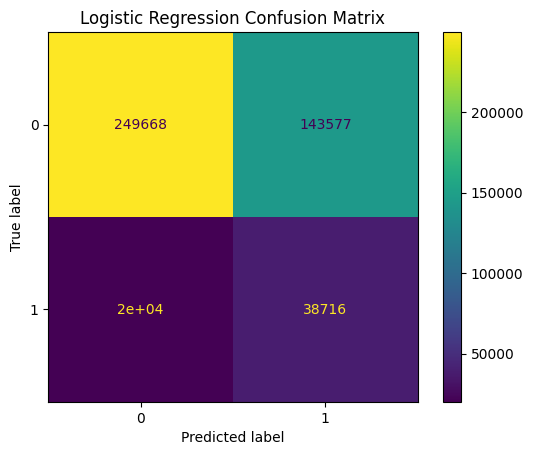

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

# random forest

In [34]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [35]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [36]:
print("="*60)
print("RANDOM FOREST RESULTS")
print("="*60)

print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")

print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")

print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")

print(f"F1 Score : {f1_score(y_test, y_pred_rf):.4f}")

print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")

RANDOM FOREST RESULTS
Accuracy : 0.8695
Precision: 0.4540
Recall   : 0.0113
F1 Score : 0.0221
ROC AUC  : 0.7069


In [37]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93    393245
           1       0.45      0.01      0.02     58883

    accuracy                           0.87    452128
   macro avg       0.66      0.50      0.48    452128
weighted avg       0.82      0.87      0.81    452128



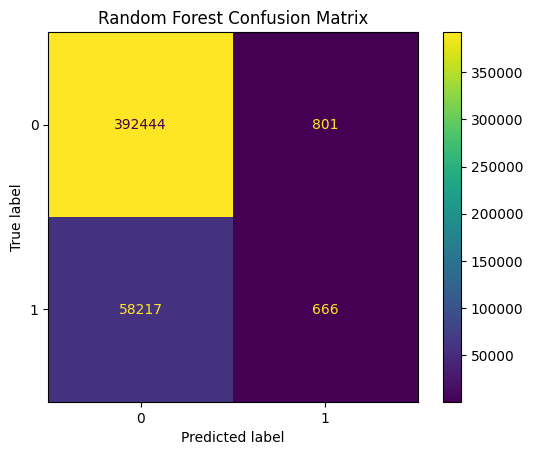

In [38]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [39]:
metrics = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf)
    ],

    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf)
    ],

    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf)
    ],

    "ROC AUC":[
        roc_auc_score(y_test,y_prob_lr),
        roc_auc_score(y_test,y_prob_rf)
    ]

})

metrics

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.637837,0.212383,0.657507,0.321060,0.703442
1,Random Forest,0.869466,0.453988,0.011311,0.022071,0.706906


In [40]:
metrics.to_csv(
    "../models/model_metrics.csv",
    index=False
)

print("Model metrics saved.")

Model metrics saved.


# featuer importance

In [41]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
2,int_rate,0.114680
11,dti,0.104141
13,revol_util,0.101379
3,installment,0.090194
6,annual_inc,0.087424
14,total_acc,0.077596
0,loan_amnt,0.066572
12,open_acc,0.063708
10,credit_score,0.061900
7,emp_length,0.049827


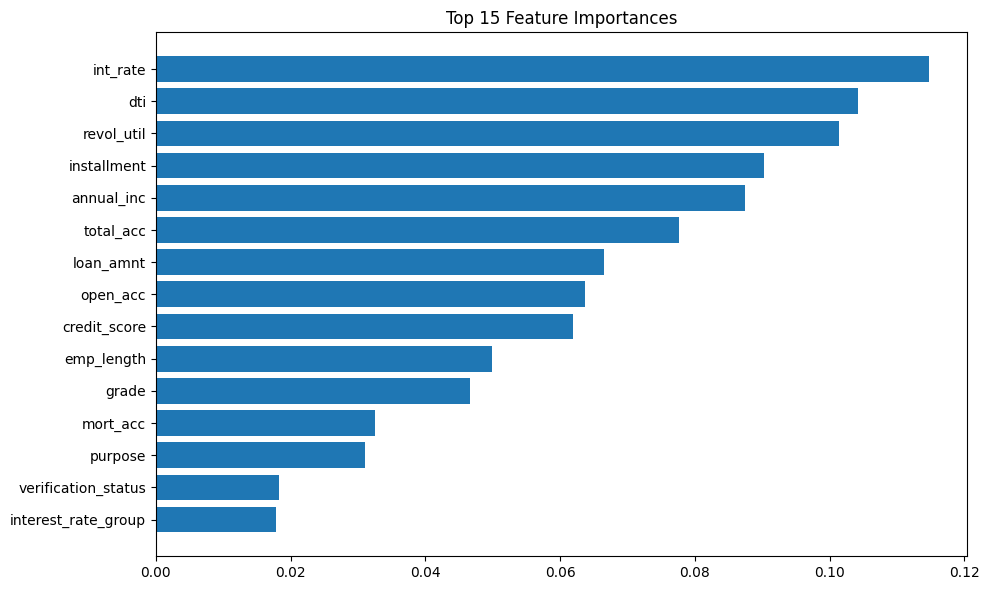

In [42]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.title("Top 15 Feature Importances")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [43]:
joblib.dump(
    logistic_model,
    "../models/logistic_regression.pkl"
)

joblib.dump(
    rf_model,
    "../models/random_forest.pkl"
)

print("Models saved successfully.")

Models saved successfully.


# optimization

In [44]:
from sklearn.model_selection import GridSearchCV

In [45]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "class_weight": ["balanced"]
}

In [46]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalt

[CV] END C=0.1, class_weight=balanced, penalty=l2, solver=lbfgs; total time=  12.1s
[CV] END C=0.01, class_weight=balanced, penalty=l2, solver=lbfgs; total time=  12.5s
[CV] END C=0.01, class_weight=balanced, penalty=l2, solver=lbfgs; total time=  12.5s


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalt

[CV] END C=0.01, class_weight=balanced, penalty=l2, solver=lbfgs; total time=  13.5s
[CV] END C=0.01, class_weight=balanced, penalty=l2, solver=lbfgs; total time=  13.9s


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV] END C=0.01, class_weight=balanced, penalty=l2, solver=lbfgs; total time=  14.6s


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV] END C=0.1, class_weight=balanced, penalty=l2, solver=lbfgs; total time=  15.4s
[CV] END C=0.1, class_weight=balanced, penalty=l2, solver=lbfgs; total time=  15.9s


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV] END C=0.1, class_weight=balanced, penalty=l2, solver=lbfgs; total time=   9.9s
[CV] END C=0.1, class_weight=balanced, penalty=l2, solver=lbfgs; total time=  10.4s
[CV] END C=1, class_weight=balanced, penalty=l2, solver=lbfgs; total time=  10.6s
[CV] END C=1, class_weight=balanced, penalty=l2, solver=lbfgs; total time=   9.2s


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalt

[CV] END C=1, class_weight=balanced, penalty=l2, solver=lbfgs; total time=   8.6s
[CV] END C=1, class_weight=balanced, penalty=l2, solver=lbfgs; total time=   7.9s
[CV] END C=1, class_weight=balanced, penalty=l2, solver=lbfgs; total time=  10.1s
[CV] END C=10, class_weight=balanced, penalty=l2, solver=lbfgs; total time=   7.7s
[CV] END C=10, class_weight=balanced, penalty=l2, solver=lbfgs; total time=   2.6s
[CV] END C=10, class_weight=balanced, penalty=l2, solver=lbfgs; total time=   3.2s
[CV] END C=10, class_weight=balanced, penalty=l2, solver=lbfgs; total time=   3.4s
[CV] END C=10, class_weight=balanced, penalty=l2, solver=lbfgs; total time=   2.7s


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': ['balanced'], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [47]:
print("Best Parameters")
print(grid_search.best_params_)

print("\nBest Cross Validation Score")
print(grid_search.best_score_)

Best Parameters
{'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}

Best Cross Validation Score
0.31999583355938993


In [48]:
best_lr = grid_search.best_estimator_

In [49]:
y_pred_best = best_lr.predict(X_test_scaled)

y_prob_best = best_lr.predict_proba(X_test_scaled)[:,1]

In [50]:
print("="*60)
print("OPTIMIZED LOGISTIC REGRESSION")
print("="*60)

print("Accuracy :", accuracy_score(y_test,y_pred_best))

print("Precision:", precision_score(y_test,y_pred_best))

print("Recall   :", recall_score(y_test,y_pred_best))

print("F1 Score :", f1_score(y_test,y_pred_best))

print("ROC AUC  :", roc_auc_score(y_test,y_prob_best))

OPTIMIZED LOGISTIC REGRESSION
Accuracy : 0.6377198492462312
Precision: 0.21233109590243046
Recall   : 0.6575582086510537
F1 Score : 0.3210064874499969
ROC AUC  : 0.7034363661915725


In [51]:
thresholds = np.arange(0.10, 0.95, 0.05)

results = []

for threshold in thresholds:

    preds = (y_prob_best >= threshold).astype(int)

    results.append({

        "Threshold": threshold,

        "Precision": precision_score(y_test,preds),

        "Recall": recall_score(y_test,preds),

        "F1 Score": f1_score(y_test,preds)

    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Precision,Recall,F1 Score
0,0.10,0.130480,0.999457,0.230826
1,0.15,0.131835,0.997656,0.232894
2,0.20,0.136733,0.990473,0.240294
3,0.25,0.145127,0.969295,0.252455
4,0.30,0.155296,0.936858,0.266427
5,0.35,0.167460,0.887047,0.281734
6,0.40,0.181405,0.820390,0.297113
7,0.45,0.195805,0.744307,0.310046
8,0.50,0.212331,0.657558,0.321006
9,0.55,0.234315,0.548427,0.328344


In [52]:
threshold_results.sort_values(
    by="F1 Score",
    ascending=False
)

,Threshold,Precision,Recall,F1 Score
9,0.55,0.234315,0.548427,0.328344
10,0.60,0.261413,0.426439,0.324130
8,0.50,0.212331,0.657558,0.321006
7,0.45,0.195805,0.744307,0.310046
11,0.65,0.293770,0.317188,0.305030
6,0.40,0.181405,0.820390,0.297113
5,0.35,0.167460,0.887047,0.281734
4,0.30,0.155296,0.936858,0.266427
12,0.70,0.329751,0.220913,0.264576
3,0.25,0.145127,0.969295,0.252455


In [53]:
best_threshold = 0.5500000000000002

In [54]:
final_predictions = (
    y_prob_best >= best_threshold
).astype(int)

In [55]:
print("="*60)
print("FINAL MODEL")
print("="*60)

print("Accuracy :", accuracy_score(y_test,final_predictions))

print("Precision:", precision_score(y_test,final_predictions))

print("Recall   :", recall_score(y_test,final_predictions))

print("F1 Score :", f1_score(y_test,final_predictions))

print("ROC AUC  :", roc_auc_score(y_test,y_prob_best))

FINAL MODEL
Accuracy : 0.7077907141340505
Precision: 0.23431457201111602
Recall   : 0.5484265407672843
F1 Score : 0.3283443991418491
ROC AUC  : 0.7034363661915725


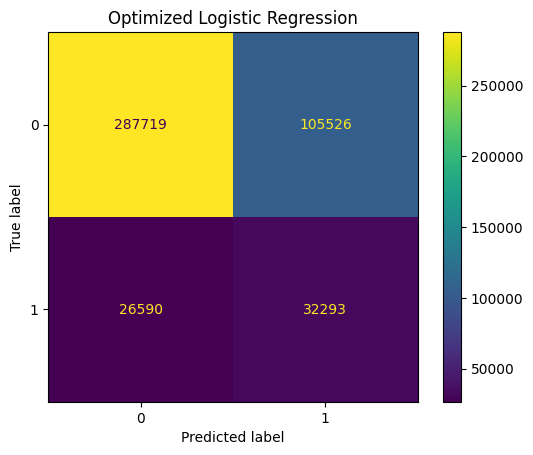

In [56]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions
)

plt.title("Optimized Logistic Regression")

plt.show()

In [57]:
comparison = pd.DataFrame({

    "Model":[
        "Original Logistic Regression",
        "Optimized Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,final_predictions),
        accuracy_score(y_test,y_pred_rf)
    ],

    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,final_predictions),
        precision_score(y_test,y_pred_rf)
    ],

    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,final_predictions),
        recall_score(y_test,y_pred_rf)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,final_predictions),
        f1_score(y_test,y_pred_rf)
    ],

    "ROC AUC":[
        roc_auc_score(y_test,y_prob_lr),
        roc_auc_score(y_test,y_prob_best),
        roc_auc_score(y_test,y_prob_rf)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Original Logistic Regression,0.637837,0.212383,0.657507,0.321060,0.703442
1,Optimized Logistic Regression,0.707791,0.234315,0.548427,0.328344,0.703436
2,Random Forest,0.869466,0.453988,0.011311,0.022071,0.706906


In [59]:
comparison.to_csv(
    "../models/model_metrics.csv",
    index=False
)

print("Model metrics saved.")

Model metrics saved.


In [60]:
joblib.dump(
    best_lr,
    "../models/final_model.pkl"
)

print("Final optimized model saved.")

Final optimized model saved.


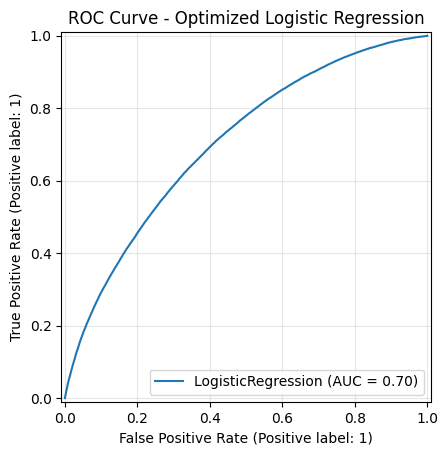

In [61]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    best_lr,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve - Optimized Logistic Regression")
plt.grid(alpha=0.3)
plt.show()

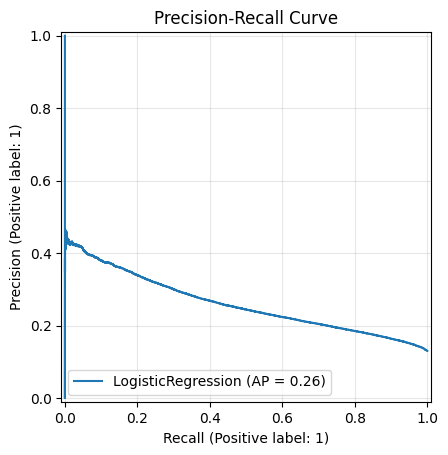

In [62]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    best_lr,
    X_test_scaled,
    y_test
)

plt.title("Precision-Recall Curve")
plt.grid(alpha=0.3)
plt.show()